In [1]:
import pandas as pd
from plotnine import *
import plotnine as p9
import numpy as np
import re

In [2]:
expe_dt = [336,386,408,481,506,646]
expe_dt = [x/24. for x in expe_dt]
expe_diam = [ 1140 , 1400 , 1590 , 2040 , 2250 , 3040 ]

In [3]:
biodynamo_dt = [14, 14.8333333333333, 15.6666666666667, 16.5, 17.3333333333333, 18.1666666666666, 18.9999999999999, 19.8333333333332, 20.6666666666665, 21.4999999999998, 22.333333333333, 23.1666666666663, 23.9999999999996, 24.8333333333329, 25.6666666666665, 26.5]
biodynamo_diam =  [1240, 1320, 1440, 1560, 1680, 1800, 1920, 2040, 2160, 2280, 2400, 2520, 2640, 2760, 2880, 3000]

In [4]:
df_tisim_pre = pd.read_csv('../Tisim/use_case_2Ddisk/2D disk.csv',sep=',',engine='python')
df_tisim_pre

,time (day),diameter (um)
0,0.0,0.00
1,0.1,0.00
2,0.2,0.00
3,0.3,0.00
4,0.4,0.00
...,...,...
255,25.5,2878.44
256,25.6,2893.82
257,25.7,2909.20
258,25.8,2925.08


In [5]:
# tisim_diam = df_tsim_pre["diameter (um)"].iloc[140:]
# tisim_dt = df_tsim_pre["time (day)"].iloc[140:]
df_tisim = df_tisim_pre.iloc[140:]
df_tisim.rename(columns={"time (day)": "dt", "diameter (um)": "diam"}, inplace=True)
df_tisim

/tmp/ipykernel_2475/2281136928.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,dt,diam
140,14.0,1089.386
141,14.1,1103.568
142,14.2,1119.310
143,14.3,1135.278
144,14.4,1151.256
...,...,...
255,25.5,2878.440
256,25.6,2893.820
257,25.7,2909.200
258,25.8,2925.080


In [6]:
with open("../Chaste/use_case_2Ddisk/results/multiple-cells/tissuewidth.dat") as results_file:
    times = []
    tissue_widths = []
    for line in results_file:
        line = line.replace('\n', '')
        values = re.split('\t|,', line)
        if len(values) == 1:
            continue
        
        times.append(float(values[0]))
        tissue_widths.append(float(values[3]))
df_chaste = pd.DataFrame(data = zip(times,tissue_widths),columns=['dt','diam'])
df_chaste["dt"]=(df_chaste["dt"]+336)/24
df_chaste


,dt,diam
0,14.000000,1130.00
1,14.020833,1139.84
2,14.041667,1145.22
3,14.062500,1149.32
4,14.083333,1152.75
...,...,...
668,27.916667,2993.03
669,27.937500,2994.11
670,27.958333,2995.45
671,27.979167,2997.17


In [7]:
# df_pc = pd.read_csv('../Physicell/output/physicell1428.csv' ,sep=',',engine='python')
# df_pc = df_pc.drop(columns=df_pc.columns[0])
df_pc_pre = pd.read_csv('../PhysiCell/results/output_monolayer/summary.csv' ,sep=',',engine='python')
df_pc_pre["timestep"] = [x/1440 for x in df_pc_pre["timestep"]]
df_pc = df_pc_pre.iloc[27:].drop(columns=df_pc_pre.columns[1])
df_pc.rename(columns={"timestep": "dt", "diameter": "diam"}, inplace=True)
df_pc

,dt,diam
27,14.0,1126.095847
28,14.5,1193.194088
29,15.0,1262.276271
30,15.5,1339.053357
31,16.0,1407.406344
32,16.5,1480.728763
33,17.0,1556.061832
34,17.5,1627.749460
35,18.0,1698.417072
36,18.5,1776.434266


In [8]:
df_exp = pd.DataFrame(data=zip(expe_dt,expe_diam),columns=['dt','diam'])
df_exp.insert(loc=2, column='Results', value='Experimental')
df_biod = pd.DataFrame(data=zip(biodynamo_dt,biodynamo_diam),columns=['dt','diam'])
df_biod.insert(loc=2, column='Results', value='BioDynaMo')
# df_tisim = pd.DataFrame(data=zip(tisim_dt,tisim_diam),columns=['dt','diam'])
df_tisim.insert(loc=2, column='Results', value='TiSim')
df_pc.insert(loc=2, column='Results', value='PhysiCell')
df_chaste.insert(loc=2,column='Results',value="Chaste")

In [9]:
frames = [df_chaste,df_tisim, df_biod, df_pc, df_exp]
df_all = pd.concat(frames)

color = {
    'Experimental': 'black', 
    'BioDynaMo': 'red', 
    'TiSim': 'orange',
    'PhysiCell': 'green',
    'Chaste': 'blue'
    }

/home/amontagud2/anaconda3/envs/studio/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


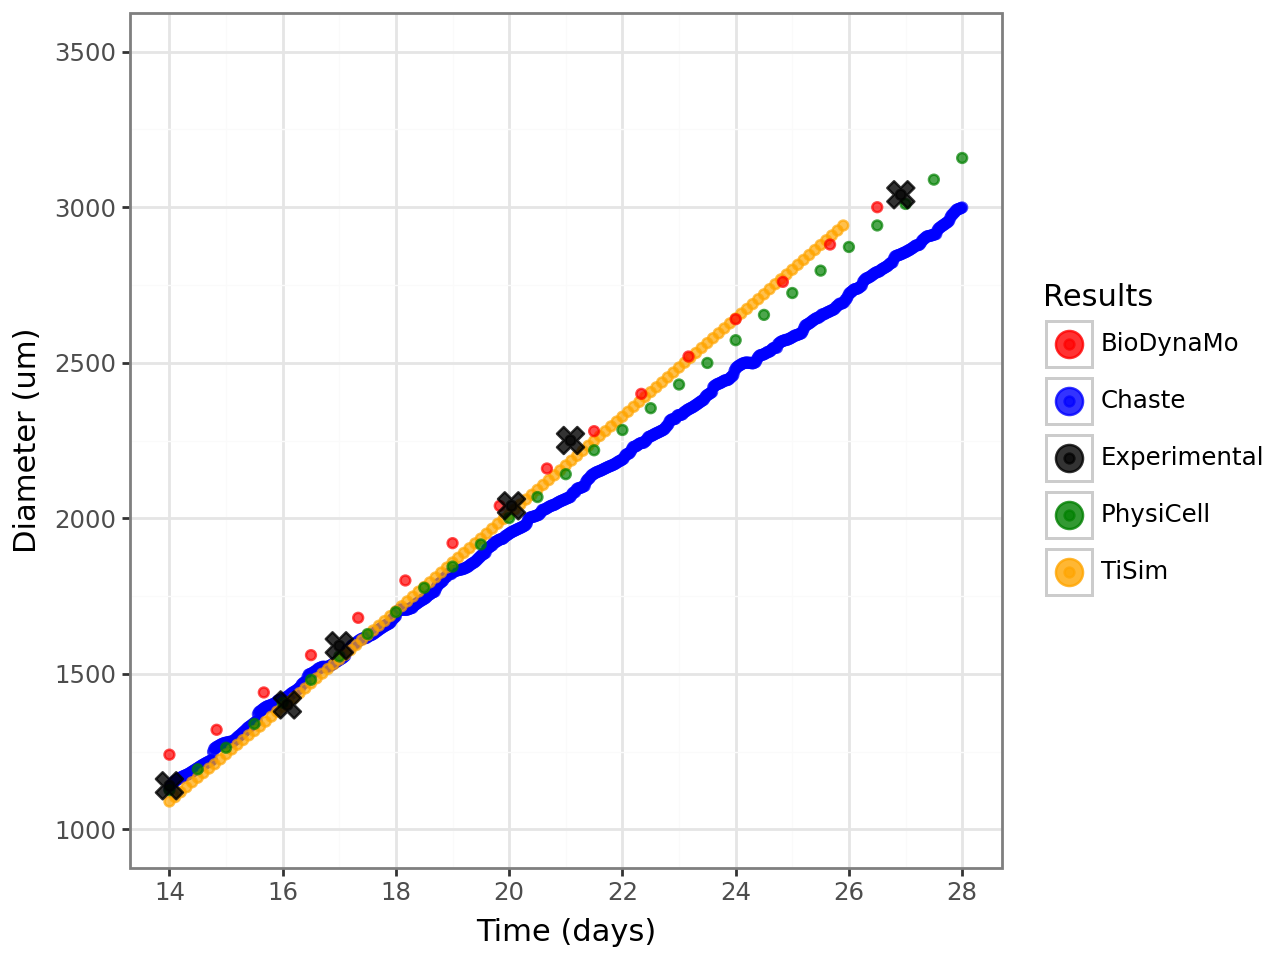

In [10]:
(
    ggplot (df_all) + 
    aes(x='dt',y='diam', colour='Results') + 
    geom_point(alpha = 0.7) +
    geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5, alpha = 0.8)+
    scale_color_manual(values=color, name="Results")+
    scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+
    scale_y_continuous(name="Diameter (um)", limits={1000, 3500}, breaks = range(0,4000,500))+
    theme_bw()+
    theme(legend_position = "right")+
    guides(colour=guide_legend(override_aes={"shape": 'o'}))
)

In [11]:
# monolayer = ggplot (df_all) + \
# aes(x='dt',y='diam', colour='Results') + \
# geom_point(alpha = 0.7) + \
# geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5)+ \
# scale_color_manual(values=color, name="Results")+\
# scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+\
# scale_y_continuous(name="Diameter (um)", limits={1000, 3500}, breaks = range(0,4000,500))+\
# theme_bw()+\
# theme(legend_position = "right")+\
# guides(colour=guide_legend(override_aes={"shape": 'o'}))

# monolayer.save(filename = 'monolayer.png', height=5, width=9, units = 'in', dpi=1000)

In [12]:
bdm_json = [
{
  "_typename" : "bdm::experimental::TimeSeries",
  "data_" : [
    {"$pair" : "pair<string,bdm::experimental::TimeSeries::Data>", "first" : "env_dims", "second" : {
    "_typename" : "bdm::experimental::TimeSeries::Data",
    "y_reducer_collector" : 0,
    "x_values" : [14, 14.8333333333333, 15.6666666666667, 16.5, 17.3333333333333, 18.1666666666666, 18.9999999999999, 19.8333333333332, 20.6666666666665, 21.4999999999998, 22.333333333333, 23.1666666666663, 23.9999999999996, 24.8333333333329, 25.6666666666665, 26.5],
    "y_values" : [1240, 1320, 1440, 1560, 1680, 1800, 1920, 2040, 2160, 2280, 2400, 2520, 2640, 2760, 2880, 3000],
    "y_error_low" : [],
    "y_error_high" : [], 
    "_blob" : [4509931920, 4509931840]
  }}, {"$pair" : "pair<string,bdm::experimental::TimeSeries::Data>", "first" : "total_cells", "second" : {
    "_typename" : "bdm::experimental::TimeSeries::Data",
    "y_reducer_collector" : 0,
    "x_values" : [14, 14.8333333333333, 15.6666666666667, 16.5, 17.3333333333333, 18.1666666666666, 18.9999999999999, 19.8333333333332, 20.6666666666665, 21.4999999999998, 22.333333333333, 23.1666666666663, 23.9999999999996, 24.8333333333329, 25.6666666666665, 26.5],
    "y_values" : [3249, 16717, 20519, 24468, 28648, 33086, 37802, 42797, 48095, 53681, 59501, 65624, 72062, 78778, 85765, 93064],
    "y_error_low" : [],
    "y_error_high" : [], 
    "_blob" : [4509931744, 4509931840]
  }}]
}
]

In [13]:
# cells vs time
# BioDynaMo

bdm_all = pd.json_normalize(
    data = bdm_json,
    record_path=['data_'],
    # record_path=['data_','second','y_values'],
    errors='ignore')

bdm_cells = bdm_all.loc[bdm_all['first'] == 'total_cells' , ['second.x_values', 'second.y_values']]
bdm_cells_x = bdm_cells.apply(lambda x: pd.Series(x['second.x_values']), axis=1)
bdm_cells_y = bdm_cells.apply(lambda x: pd.Series(x['second.y_values']), axis=1)
bdm_cells2 = pd.concat([bdm_cells_x, bdm_cells_y], axis=0).transpose()
# bdm_cells2 = pd.concat([bdm_cells2, df_biod], axis=1)
bdm_cells2.columns = ['dt','cells']
bdm_cells3 = bdm_cells2.merge(df_biod,on='dt', how='left')
bdm_cells3["cells^1/2"]=np.power(bdm_cells3["cells"],1/2)
bdm_cells3["diam/cells"]=bdm_cells3["diam"]/bdm_cells3["cells"]
bdm_cells3

,dt,cells,diam,Results,cells^1/2,diam/cells
0,14.000000,3249.0,1240,BioDynaMo,57.000000,0.381656
1,14.833333,16717.0,1320,BioDynaMo,129.294238,0.078962
2,15.666667,20519.0,1440,BioDynaMo,143.244546,0.070179
3,16.500000,24468.0,1560,BioDynaMo,156.422505,0.063757
4,17.333333,28648.0,1680,BioDynaMo,169.257201,0.058643
5,18.166667,33086.0,1800,BioDynaMo,181.895574,0.054404
6,19.000000,37802.0,1920,BioDynaMo,194.427364,0.050791
7,19.833333,42797.0,2040,BioDynaMo,206.874358,0.047667
8,20.666667,48095.0,2160,BioDynaMo,219.305723,0.044911
9,21.500000,53681.0,2280,BioDynaMo,231.691605,0.042473


In [14]:
# cells vs time
# TiSim - OLD RESULTS

df_tisim_pre2 = pd.read_csv('../Tisim/use_case_2Ddisk/old_results/result_2d_10_8_3.9_50.txt',sep='\t',engine='python')

tisim_dt2 = [x/86400 for x in df_tisim_pre2['Time [s]'].iloc[140:]]
tisim_cells = [x for x in df_tisim_pre2["numCells (all)"].iloc[140:]]
df_tisim_cells = pd.DataFrame(data=zip(tisim_dt2,tisim_cells),columns=['dt','cells'])
df_tisim_cells2 = df_tisim_cells.merge(df_tisim, on='dt', how='left')
df_tisim_cells2["cells^1/2"]=np.power(df_tisim_cells2["cells"],1/2)
df_tisim_cells2["diam/cells"]=df_tisim_cells2["diam"]/df_tisim_cells2["cells"]

df_tisim_cells2



,dt,cells,diam,Results,cells^1/2,diam/cells
0,14.0,19514,1089.386,TiSim,139.692519,0.055826
1,14.1,20038,1103.568,TiSim,141.555643,0.055074
2,14.2,20659,1119.310,TiSim,143.732390,0.054180
3,14.3,21293,1135.278,TiSim,145.921212,0.053317
4,14.4,21897,1151.256,TiSim,147.976349,0.052576
...,...,...,...,...,...,...
115,25.5,142887,2878.440,TiSim,378.003968,0.020145
116,25.6,144427,2893.820,TiSim,380.035525,0.020037
117,25.7,145974,2909.200,TiSim,382.065439,0.019930
118,25.8,147588,2925.080,TiSim,384.171837,0.019819


In [15]:
# Chaste
with open("../Chaste/use_case_2Ddisk/results/multiple-cells/tissuewidth.dat") as results_file:
    times = []
    tissue_widths = []
    num_cells = []
    for line in results_file:
        line = line.replace('\n', '')
        values = re.split('\t|,', line)
        if len(values) == 1:
            continue
        
        times.append(float(values[0]))
        tissue_widths.append(float(values[3]))
        num_cells.append(int(values[4]))
        
df_chaste_cells = pd.DataFrame(data = zip(times,tissue_widths,num_cells),columns=['dt','diam','cells'])
df_chaste_cells["dt"]=(df_chaste_cells["dt"]+336)/24
df_chaste_cells["cells^1/2"]=np.power(df_chaste_cells["cells"],1/2)
df_chaste_cells["diam/cells"]=df_chaste_cells["diam"]/df_chaste_cells["cells"]
df_chaste_cells.insert(loc=2,column='Results',value="Chaste")
df_chaste_cells


,dt,diam,Results,cells,cells^1/2,diam/cells
0,14.000000,1130.00,Chaste,2929,54.120237,0.385797
1,14.020833,1139.84,Chaste,2929,54.120237,0.389157
2,14.041667,1145.22,Chaste,2929,54.120237,0.390994
3,14.062500,1149.32,Chaste,2929,54.120237,0.392393
4,14.083333,1152.75,Chaste,2929,54.120237,0.393564
...,...,...,...,...,...,...
668,27.916667,2993.03,Chaste,15813,125.749751,0.189277
669,27.937500,2994.11,Chaste,15839,125.853089,0.189034
670,27.958333,2995.45,Chaste,15877,126.003968,0.188666
671,27.979167,2997.17,Chaste,15895,126.075374,0.188561


In [16]:
# PhysiCell
# PhysiCell: not available
# df_pc = pd.read_csv('../Physicell/output/physicell1428.csv' ,sep=',',engine='python')
# df_pc = df_pc.drop(columns=df_pc.columns[0])
# df_pc = df_pc.rename(columns={"Time (s)": "dt"})
# df_pc["dt"] = df_pc["dt"]/86400
# df_pc["Results"] = "PhysiCell"
# df_pc
# df_pc = pd.read_csv('../Physicell/output/physicell1428.csv' ,sep=',',engine='python')
# df_pc = df_pc.drop(columns=df_pc.columns[0])
# df_pc_pre = pd.read_csv('../PhysiCell/results/output_monolayer/summary.csv' ,sep=',',engine='python')
# df_pc_pre["timestep"] = [x/1440 for x in df_pc_pre["timestep"]]
# df_pc = df_pc_pre.iloc[27:].drop(columns=df_pc_pre.columns[1])
# df_pc.rename(columns={"timestep": "dt", "diameter": "diam"}, inplace=True)
df_pc_cells = df_pc_pre.iloc[27:]#.drop(columns=df_pc_pre.columns[2])
df_pc_cells.rename(columns={"timestep": "dt", "cell_count": "cells", "diameter": "diam"}, inplace=True)
# df_pc.rename(columns={"timestep": "dt", "diameter": "diam"}, inplace=True)

df_pc_cells["cells^1/2"]=np.power(df_pc_cells["cells"],1/2)
df_pc_cells["diam/cells"]=df_pc_cells["diam"]/df_pc_cells["cells"]
df_pc_cells.insert(loc=2, column='Results', value='PhysiCell')
df_pc_cells

/tmp/ipykernel_2475/3796142689.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2475/3796142689.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_2475/3796142689.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,dt,cells,Results,diam,cells^1/2,diam/cells
27,14.0,15054,PhysiCell,1126.095847,122.694743,0.074804
28,14.5,15906,PhysiCell,1193.194088,126.118991,0.075015
29,15.0,18639,PhysiCell,1262.276271,136.524723,0.067722
30,15.5,21580,PhysiCell,1339.053357,146.901327,0.062051
31,16.0,22641,PhysiCell,1407.406344,150.469266,0.062162
32,16.5,25898,PhysiCell,1480.728763,160.928556,0.057175
33,17.0,29299,PhysiCell,1556.061832,171.169507,0.053110
34,17.5,30623,PhysiCell,1627.749460,174.994286,0.053154
35,18.0,34346,PhysiCell,1698.417072,185.326738,0.049450
36,18.5,38297,PhysiCell,1776.434266,195.696193,0.046386


In [17]:
# no exp

# bdm_cells2.insert(loc=2, column='Results', value='BioDynaMo')
# df_tisim_cells.insert(loc=2, column='Results', value='TiSim')
# df_pc_cells.insert(loc=2, column='Results', value='PhysiCell')
# df_chaste_cells.insert(loc=2,column='Results',value="Chaste")

In [18]:
# frames = [df_chaste,df_tisim, df_biod, df_pc, df_exp]
frames = [df_chaste_cells, df_tisim_cells2, bdm_cells3, df_pc_cells]
df_all = pd.concat(frames)

color = {
    'Experimental': 'black', 
    'BioDynaMo': 'red', 
    'TiSim': 'orange',
    'PhysiCell': 'green',
    'Chaste': 'blue'
    }

/home/amontagud2/anaconda3/envs/studio/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


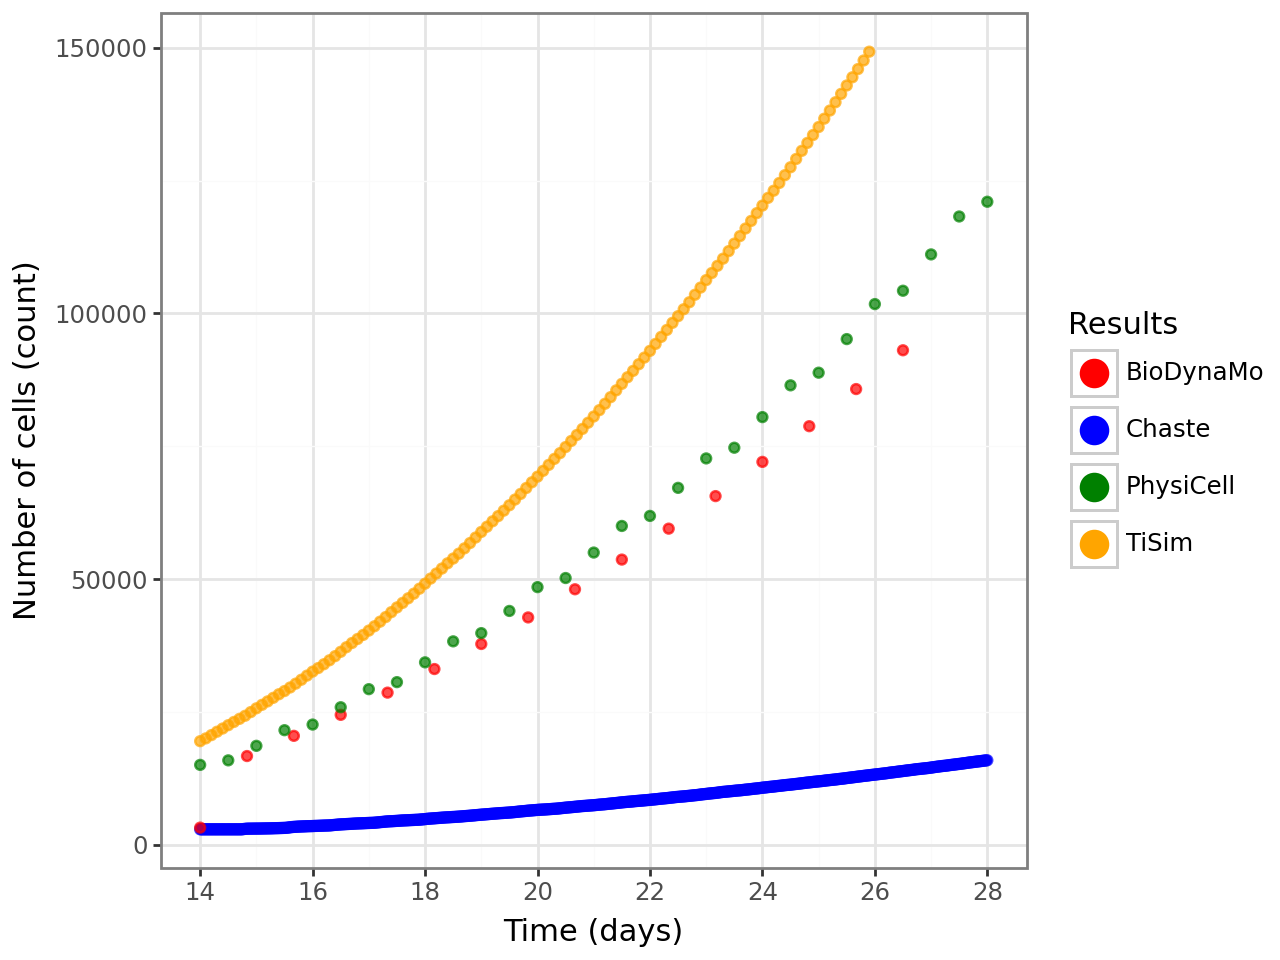

In [19]:
(
    ggplot (df_all) + 
    aes(x='dt',y='cells', colour='Results') + 
    geom_point(alpha = 0.7) +
    geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5)+
    scale_color_manual(values=color, name="Results")+
    scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+
    # scale_y_continuous(name="Number of cells (count)", limits={1000, 3500}, breaks = range(0,4000,500))+
    scale_y_continuous(name="Number of cells (count)")+
    theme_bw()+
    theme(legend_position = "right")+
    guides(colour=guide_legend(override_aes={"shape": 'o'}))
)

/home/amontagud2/anaconda3/envs/studio/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


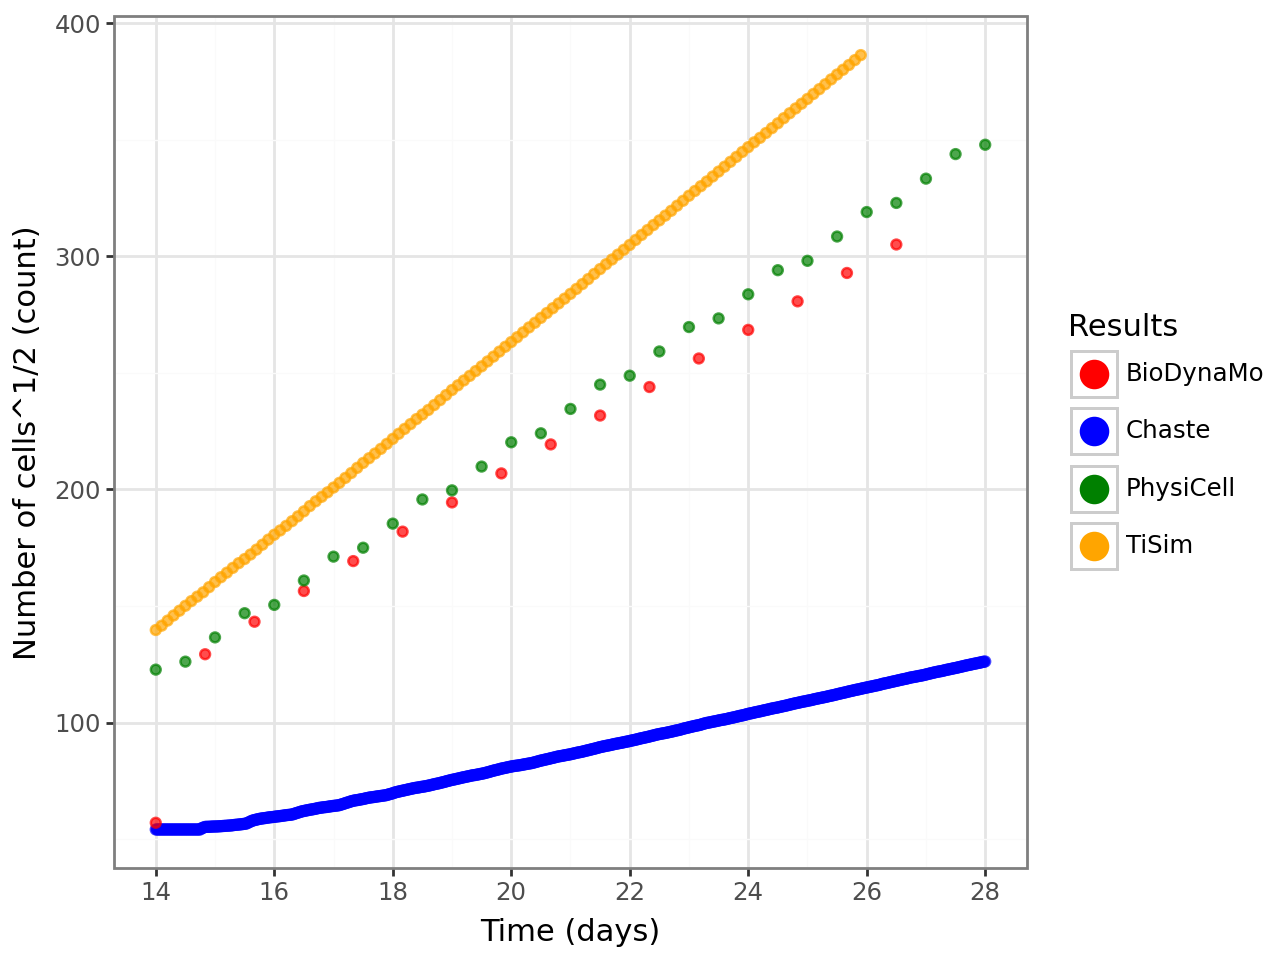

In [ ]:
(
    ggplot (df_all) + 
    aes(x='dt',y='cells^1/2', colour='Results') + 
    geom_point(alpha = 0.7) +
    geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5)+
    scale_color_manual(values=color, name="Results")+
    scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+
    # scale_y_continuous(name="Number of cells (count)", limits={1000, 3500}, breaks = range(0,4000,500))+
    scale_y_continuous(name="Number of cells^1/2 (count)")+
    theme_bw()+
    theme(legend_position = "right")+
    guides(colour=guide_legend(override_aes={"shape": 'o'}))
)

/home/amontagud2/anaconda3/envs/studio/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


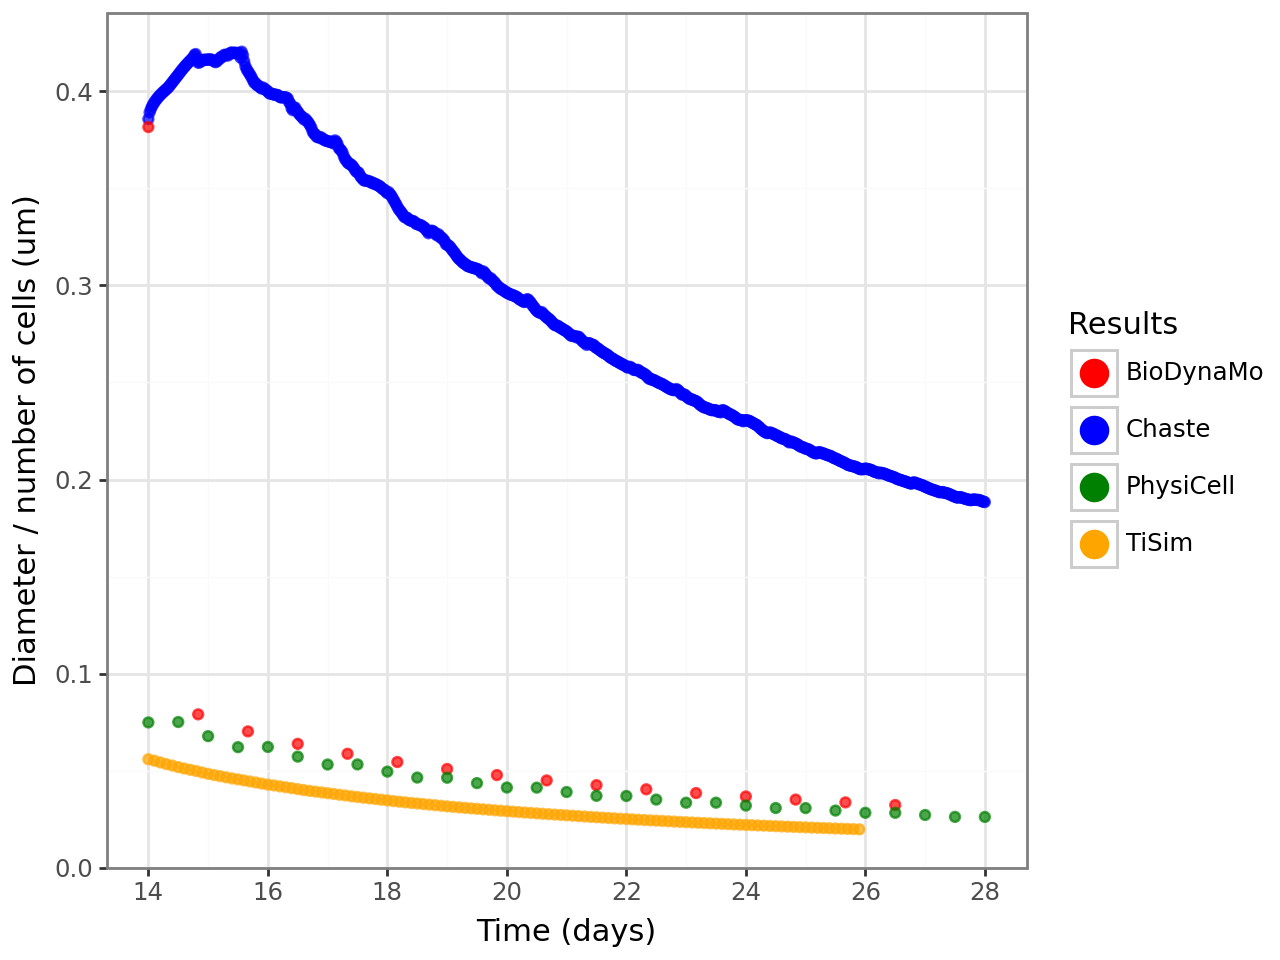

In [24]:
(
    ggplot (df_all) + 
    aes(x='dt',y='diam/cells', colour='Results') + 
    geom_point(alpha = 0.7) +
    geom_point(data=df_all.query("Results == 'Experimental' "), shape="X", size=5)+
    scale_color_manual(values=color, name="Results")+
    scale_x_continuous(name="Time (days)", limits={14, 28}, breaks = range(14,30,2))+
    # scale_y_continuous(name="Number of cells (count)", limits={1000, 3500}, breaks = range(0,4000,500))+
    scale_y_continuous(name="Diameter / number of cells (um)")+
    theme_bw()+
    theme(legend_position = "right")+
    guides(colour=guide_legend(override_aes={"shape": 'o'}))
)